# Axicon 2 (5° pair, L12 = 240 mm) — the collimated annulus, 6–10 cm after axicon 2

**Dataset**: `auto_scan-2026-07-28_18-47-47` (placement `jul28_axicon2_001`),
the first scan **after axicon 2**: 5 X–Z slices at 1 cm pitch,
y = 6–10 cm (`MeasuredFrom: "axicon2"`). Input = post-telescope Gaussian,
D = 9.50 mm (1/e² **diameter**, w₀ = 4.75 mm); axicons 1 and 2 both 5°,
L12 = 240 mm. What axicon 2 *receives* at this L12 is characterized in
`axicon1_bessel_analysis_2026_07_28` §annulus: a still-forming ring
(L12/zmax = 2.0, below the ~2.4–2.7×zmax clean-annulus threshold) with the
residual core alive at its center.

**Predictions** (650 nm, n = 1.4585, no fitted parameters):

| quantity | value |
|---|---|
| deflection after one axicon θ = k_r/k | 40.1 mrad |
| zmax = w₀/θ | 118.4 mm |
| geometric ring radius θ·L12 | 9.63 mm |
| QDHT ring peak radius at 6–10 cm | 6.8–7.0 mm |
| QDHT ring outer edge (half-max) | 8.64–8.69 mm, ≈constant in y |

Axicon 2 cancels the cone: every ray that has crossed the axis before 240 mm
(all of them, for h < θ·L12 = 9.63 mm ≈ 2·w₀) leaves parallel, so the annulus
profile should be **frozen** over these 4 cm — the collimation check is the
point of this scan. Questions: (1) is the profile frozen (residual cone
angle, axis tilt vs the gantry Y)? (2) radial profile vs the QDHT pair
model; (3) azimuthal uniformity; (4) is the brightness consistent with what
axicon 1 handed off?

**Provenance**: all five headless calibrations hit the 60-iteration limit in
the *dim* branch (robust max ~152 at 0.25–0.31 s exposures, 1–2 "saturated"
pixels reported at the calibration point) — but every **raster** frame is
unsaturated (`SaturatedPixelCount = 0`, maxes 93–185), so no slice is
flagged under the jul28 rule (`lower_bound` or saturation above 10 ms).
Absolute rates are ~10⁴ below the axicon-1 core zone — the annulus is spread
over ~2×10² mm², hence the long exposures. Why the dim branch reports
saturated pixels at all (hot pixels? the bright speck at the center blemish,
below?) is an open item for the calibration code, not for this dataset.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from simulator.qdht_axicon import simulate_axicon_pair, mm as MM

RUN = REPO / "profiler/data/auto_scan-2026-07-28_18-47-47"
SETUP = json.load(open(RUN / "auto_scan_setup.json"))
OPTIC = SETUP["Metadata"]["OpticConfiguration"]
PX_UM = 3.45
PX_MM = PX_UM * 1e-3 * 8          # composites are 8x8-downsampled

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "axicon2_annulus_analysis_2026_07_28"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(description):
    p = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(p, dpi=150, bbox_inches="tight")
    print(f"saved {p}")

slices = []
for sd in sorted(RUN.glob("y*cm")):
    manifest = [json.loads(l) for l in open(sd / "frames.jsonl")]
    lit = [m for m in manifest if m["Extra"].get("ScanKind") != "Background"
           and "-dark" not in m["Path"]]
    meta = json.load(open(sd / "composite_meta.json"))
    cal = json.load(open(sd / "calibration_result.json"))
    exp = cal["FinalExposure_us"]
    slices.append(dict(
        name=sd.name, dir=sd, y_cm=meta["BeamY_mm"] / 10, exp_us=exp,
        n_lit=len(lit), n_sat=sum(m["SaturatedPixelCount"] for m in lit),
        max_counts=max(m["Max"] for m in lit),
        peak_rate=max(m["Max"] / exp for m in lit),   # counts/us, full-res
        meta=meta, converged=cal["Converged"]))

print(f"{'slice':<12}{'y cm':>6}{'exp ms':>8}{'lit':>5}{'satpx':>6}"
      f"{'max':>5}{'peak c/us':>11}{'cal':>6}")
for s in slices:
    print(f"{s['name']:<12}{s['y_cm']:>6.0f}{s['exp_us'] / 1e3:>8.0f}"
          f"{s['n_lit']:>5}{s['n_sat']:>6}{s['max_counts']:>5}"
          f"{s['peak_rate']:>11.2e}{str(s['converged']):>6}")

slice         y cm  exp ms  lit satpx  max  peak c/us   cal
y0006.00cm       6     310   28     0  185   5.97e-04 False
y0007.00cm       7     278   28     0  170   6.12e-04 False
y0008.00cm       8     247   27     0  146   5.92e-04 False
y0009.00cm       9     269   27     0  166   6.16e-04 False
y0010.00cm      10     248   27     0  144   5.80e-04 False


## X–Z slice gallery

Composites as built by the scan (8×8-downsampled 27.6 µm pixels, background
subtracted, dark frames excluded, already rotated to machine axes; row 0 =
Z_max). Counts ÷ slice exposure → counts/µs; per-panel sqrt normalization.
The concentric fringes inside the outer edge are the diffraction of the
sharp geometric caustus at θ·L12 — real structure, not stitching. The small
dark oval at center (with a bright speck on its rim) repeats identically in
all five slices → it lives on the optic, not in the beam; zoomed below.

saved images/axicon2_annulus_analysis_2026_07_28/xz_slice_gallery.png


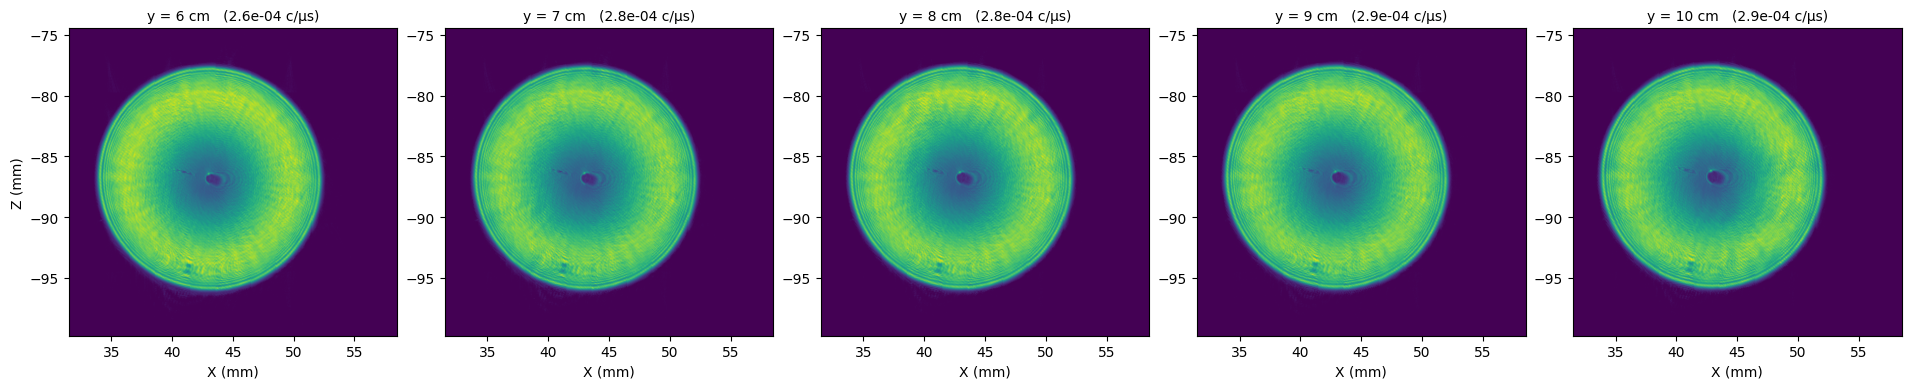

In [2]:
def load_composite(s):
    c = np.nan_to_num(np.load(s["dir"] / "composite.npy")).astype(float)
    e = s["meta"]["Extent_mm"]
    X = e["XMin"] + (np.arange(c.shape[1]) + .5) * PX_MM
    Z = e["ZMax"] - (np.arange(c.shape[0]) + .5) * PX_MM
    return c / s["exp_us"], X, Z          # counts/us

fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), constrained_layout=True)
for ax, s in zip(axes, slices):
    c, X, Z = load_composite(s)
    im = ax.imshow(np.sqrt(c / c.max()), cmap="viridis", vmin=0, vmax=1,
                   extent=[X[0], X[-1], Z[-1], Z[0]], aspect="equal")
    ax.set_title(f"y = {s['y_cm']:g} cm   ({c.max():.1e} c/µs)", fontsize=10)
    ax.set_xlabel("X (mm)")
axes[0].set_ylabel("Z (mm)")
save_fig("xz_slice_gallery")
plt.show()

saved images/axicon2_annulus_analysis_2026_07_28/center_blemish.png


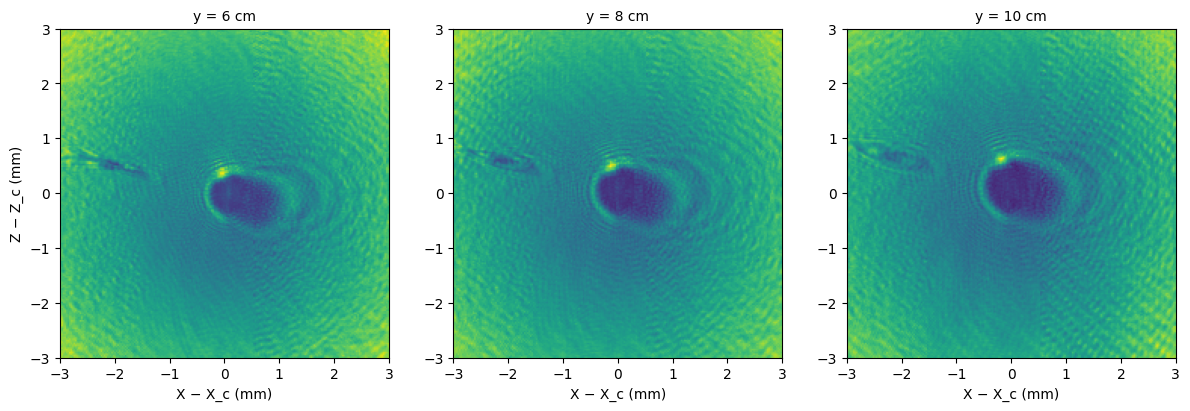

In [3]:
# --- the fixed blemish at center --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, s in zip(axes, [slices[0], slices[2], slices[4]]):
    c, X, Z = load_composite(s)
    cx, cz = 43.0, -86.8                  # ~ring center (fit below)
    iz = np.searchsorted(-Z, -(cz + 3)), np.searchsorted(-Z, -(cz - 3))
    ix = np.searchsorted(X, cx - 3), np.searchsorted(X, cx + 3)
    crop = c[iz[0]:iz[1], ix[0]:ix[1]]
    ax.imshow(np.sqrt(crop / crop.max()), cmap="viridis", vmin=0, vmax=1,
              extent=[-3, 3, -3, 3])
    ax.set_title(f"y = {s['y_cm']:g} cm", fontsize=10)
    ax.set_xlabel("X − X_c (mm)")
axes[0].set_ylabel("Z − Z_c (mm)")
save_fig("center_blemish")
plt.show()

## Ring geometry — center, outer edge, collimation

Per slice: intensity centroid seeds 360 azimuthal rays; on each ray the
outer edge is where the profile first falls below half its ray-peak beyond
the peak; a Taubin-style algebraic circle fit of the 360 edge points gives
center and outer radius R₅₀. Linear fits of center and R₅₀ vs y give the
annulus axis tilt relative to the gantry Y axis and the residual cone
angle — R₅₀ vs y is a *relative* measurement, so the estimator's absolute
offset drops out. Ring peak radius and FWHM come from the azimuthal-mean
radial profile (r > 2 mm); the QDHT comparator (N = 8192, domain R = 26 mm
so k_r,max = 2.6·k_r and the annulus stays off the domain wall) gets a
0.3 mm boxcar before the same metrics — its ring top carries ~0.1 mm
fringes that the data's azimuthal average washes out, and without the
smoothing the model peak radius jumps fringe-to-fringe between planes.
Half-max *edge* positions are estimator-sensitive here because the edge
shoulder fringe sits right at the half level (ray-fit reads ~8.5 mm, the
azimuthal-mean profile ~9.1 mm, model 8.7 mm) — shape comparison belongs
to the profile overlay below, not to a single number.

In [4]:
def ring_fit(c, X, Z):
    XX, ZZ = np.meshgrid(X, Z)
    cx, cz = (c * XX).sum() / c.sum(), (c * ZZ).sum() / c.sum()
    th = np.linspace(0, 2 * np.pi, 361)[:-1]
    rr = np.arange(0.2, 12.5, PX_MM / 2)
    edge = np.full_like(th, np.nan)
    for i, t in enumerate(th):
        ix = (cx + rr * np.cos(t) - X[0]) / PX_MM
        iz = (Z[0] - (cz + rr * np.sin(t))) / PX_MM
        p = map_coordinates(c, [iz, ix], order=1, mode="constant", cval=0.0)
        j = np.argmax(p)
        beyond = np.where(p[j:] < 0.5 * p[j])[0]
        if len(beyond):
            edge[i] = rr[j + beyond[0]]
    ok = np.isfinite(edge)
    xe = cx + edge[ok] * np.cos(th[ok])
    ze = cz + edge[ok] * np.sin(th[ok])
    A = np.c_[xe, ze, np.ones_like(xe)]
    sol, *_ = np.linalg.lstsq(A, xe**2 + ze**2, rcond=None)
    xc, zc = sol[0] / 2, sol[1] / 2
    R = np.sqrt(sol[2] + xc**2 + zc**2)
    return xc, zc, R, (np.hypot(xe - xc, ze - zc) - R).std()

def profile_metrics(r_mm, I, r_min=2.0):
    # ring peak radius, FWHM, and outer half-max radius (r > r_min)
    i0 = np.searchsorted(r_mm, r_min)
    j = i0 + np.argmax(I[i0:])
    half = 0.5 * I[j]
    lo = np.where(I[i0:j] < half)[0]
    hi = np.where(I[j:] < half)[0]
    r50 = r_mm[j + hi[0]] if len(hi) else np.nan
    fwhm = (r50 - r_mm[i0 + lo[-1]]) if len(lo) and len(hi) else np.nan
    return r_mm[j], fwhm, r50

for s in slices:
    c, X, Z = load_composite(s)
    s["xc"], s["zc"], s["R50"], s["edge_std"] = ring_fit(c, X, Z)
    XX, ZZ = np.meshgrid(X, Z)
    r = np.hypot(XX - s["xc"], ZZ - s["zc"])
    rb = np.arange(0, 12.5, PX_MM)
    idx = np.digitize(r.ravel(), rb)
    hits = np.bincount(idx, minlength=len(rb) + 1)[1:len(rb)]
    s["r_mm"] = rb[:-1] + PX_MM / 2
    s["prof"] = (np.bincount(idx, weights=c.ravel(),
                             minlength=len(rb) + 1)[1:len(rb)]
                 / np.maximum(hits, 1))
    s["r_peak"], s["fwhm"], _ = profile_metrics(s["r_mm"], s["prof"])
    s["theta_deg"] = np.degrees(np.arctan2(ZZ - s["zc"], XX - s["xc"]))
    s["rgrid"] = r
    s["canvas"] = c

In [5]:
# --- QDHT pair model at the five planes -------------------------------------
pair = simulate_axicon_pair(
    D=OPTIC["GaussianBeamWaist_mm"] * MM,        # records the 1/e^2 diameter
    alpha_deg=OPTIC["Axicon1_deg"], L_sep=OPTIC["L12_mm"] * MM,
    z_after=110 * MM, N=8192, Nz1=8, Nz2=23,
    pad=26 * MM - 0.00963)                       # domain wall at 26 mm
q = pair["q"]
assert q.kr_max > 2.5 * pair["kr"], "radial grid too coarse for the cone"

r_eval = np.arange(0, 12.5, PX_MM) * 1e-3
EV = q.eval_matrix(r_eval)
BOX = np.ones(11) / 11                          # 0.3 mm boxcar (model only)
model = {}
for s in slices:
    iz = np.argmin(np.abs(pair["z2"] - s["y_cm"] * 1e-2))
    I = np.abs(pair["Y2"][iz] @ EV) ** 2
    model[s["y_cm"]] = dict(I=I, m=profile_metrics(r_eval * 1e3,
                                                   np.convolve(I, BOX, "same")))

print(f"{'y cm':>5} | {'R50 ray-fit':>11}{'+/-':>5} | "
      f"{'meas peak_r':>11}{'fwhm':>6} | {'model peak_r':>12}{'fwhm':>6}")
for s in slices:
    mp, mf, _ = model[s["y_cm"]]["m"]
    print(f"{s['y_cm']:>5.0f} | {s['R50']:>11.3f}{s['edge_std']:>5.2f} | "
          f"{s['r_peak']:>11.2f}{s['fwhm']:>6.2f} | {mp:>12.2f}{mf:>6.2f}")

ys = np.array([s["y_cm"] for s in slices]) * 10          # mm
def fit(v):
    (a, b), cov = np.polyfit(ys, v, 1, cov=True)
    return a, np.sqrt(cov[0, 0]), b
sx, dsx, _ = fit([s["xc"] for s in slices])
sz, dsz, _ = fit([s["zc"] for s in slices])
sr, dsr, _ = fit([s["R50"] for s in slices])
mrs, _, _ = fit([profile_metrics(r_eval * 1e3,
                                 np.convolve(model[s["y_cm"]]["I"], BOX,
                                             "same"))[2] for s in slices])
print(f"\naxis tilt vs gantry Y:  dX/dy = {sx * 1e3:+.1f} ± {dsx * 1e3:.1f} mrad,"
      f"  dZ/dy = {sz * 1e3:+.1f} ± {dsz * 1e3:.1f} mrad")
print(f"residual cone (R50 slope): {sr * 1e3:+.1f} ± {dsr * 1e3:.1f} mrad"
      f"  (QDHT edge slope {mrs * 1e3:+.1f} mrad)")

alpha=5.0 x2  D=9.5 mm  L=240 mm | zmax= 118.4 mm  ring= 9.63 mm |  5.1 pts/fringe, kr_max/kr= 2.6, wall margin= 3.4 w0


 y cm | R50 ray-fit  +/- | meas peak_r  fwhm | model peak_r  fwhm
    6 |       8.542 0.23 |        7.05  5.02 |         6.82  4.36
    7 |       8.472 0.30 |        6.97  5.33 |         6.76  4.36
    8 |       8.470 0.26 |        6.94  5.35 |         6.79  4.36
    9 |       8.466 0.25 |        7.00  5.02 |         6.87  4.33
   10 |       8.368 0.32 |        7.02  5.30 |         6.84  4.36

axis tilt vs gantry Y:  dX/dy = -4.2 ± 0.4 mrad,  dZ/dy = +4.8 ± 1.6 mrad
residual cone (R50 slope): -3.5 ± 1.0 mrad  (QDHT edge slope -0.3 mrad)


saved images/axicon2_annulus_analysis_2026_07_28/ring_geometry.png


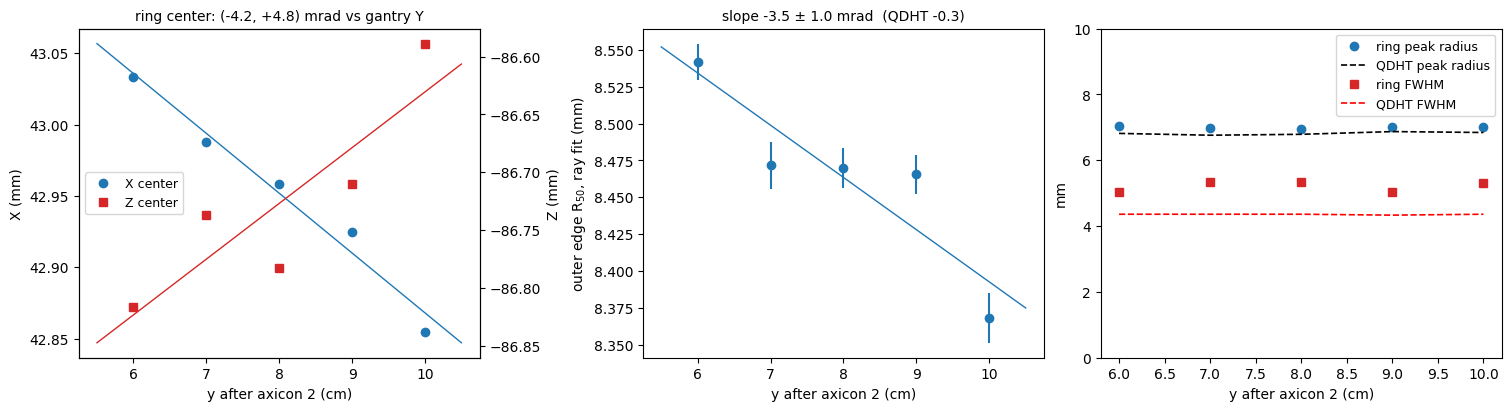

In [6]:
# --- ring geometry figure ----------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
yy = np.linspace(55, 105, 2)

ax = axs[0]
xc = [s["xc"] for s in slices]
ax.plot(ys / 10, xc, "o", color="tab:blue", label="X center")
ax.plot(yy / 10, np.polyval(np.polyfit(ys, xc, 1), yy), "-",
        color="tab:blue", lw=1)
ax.set_xlabel("y after axicon 2 (cm)"); ax.set_ylabel("X (mm)")
ax2 = ax.twinx()
zc = [s["zc"] for s in slices]
ax2.plot(ys / 10, zc, "s", color="tab:red", label="Z center")
ax2.plot(yy / 10, np.polyval(np.polyfit(ys, zc, 1), yy), "-",
         color="tab:red", lw=1)
ax2.set_ylabel("Z (mm)")
ax.set_title(f"ring center: ({sx * 1e3:+.1f}, {sz * 1e3:+.1f}) mrad vs gantry Y",
             fontsize=10)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center left", fontsize=9)

ax = axs[1]
ax.errorbar(ys / 10, [s["R50"] for s in slices],
            yerr=[s["edge_std"] / np.sqrt(360) for s in slices],
            fmt="o", color="tab:blue")
ax.plot(yy / 10, np.polyval(np.polyfit(ys, [s["R50"] for s in slices], 1), yy),
        "-", color="tab:blue", lw=1)
ax.set_xlabel("y after axicon 2 (cm)")
ax.set_ylabel("outer edge R$_{50}$, ray fit (mm)")
ax.set_title(f"slope {sr * 1e3:+.1f} ± {dsr * 1e3:.1f} mrad"
             f"  (QDHT {mrs * 1e3:+.1f})", fontsize=10)

ax = axs[2]
ax.plot(ys / 10, [s["r_peak"] for s in slices], "o", color="tab:blue",
        label="ring peak radius")
ax.plot(ys / 10, [model[s["y_cm"]]["m"][0] for s in slices], "k--", lw=1.2,
        label="QDHT peak radius")
ax.plot(ys / 10, [s["fwhm"] for s in slices], "s", color="tab:red",
        label="ring FWHM")
ax.plot(ys / 10, [model[s["y_cm"]]["m"][1] for s in slices], "r--", lw=1.2,
        label="QDHT FWHM")
ax.set_xlabel("y after axicon 2 (cm)"); ax.set_ylabel("mm")
ax.set_ylim(0, 10); ax.legend(fontsize=9)
save_fig("ring_geometry")
plt.show()

## Radial profile and azimuthal uniformity

Azimuthal-mean radial profile about each slice's fitted center, normalized
to its ring-band peak, against the QDHT model at the same planes. The
azimuthal panel averages counts in the 5.5–8.0 mm ring band per 4° sector,
normalized to the band mean — sensitive to what axicon 3 will fold into the
Bessel window at each azimuth.

saved images/axicon2_annulus_analysis_2026_07_28/annulus_profiles.png


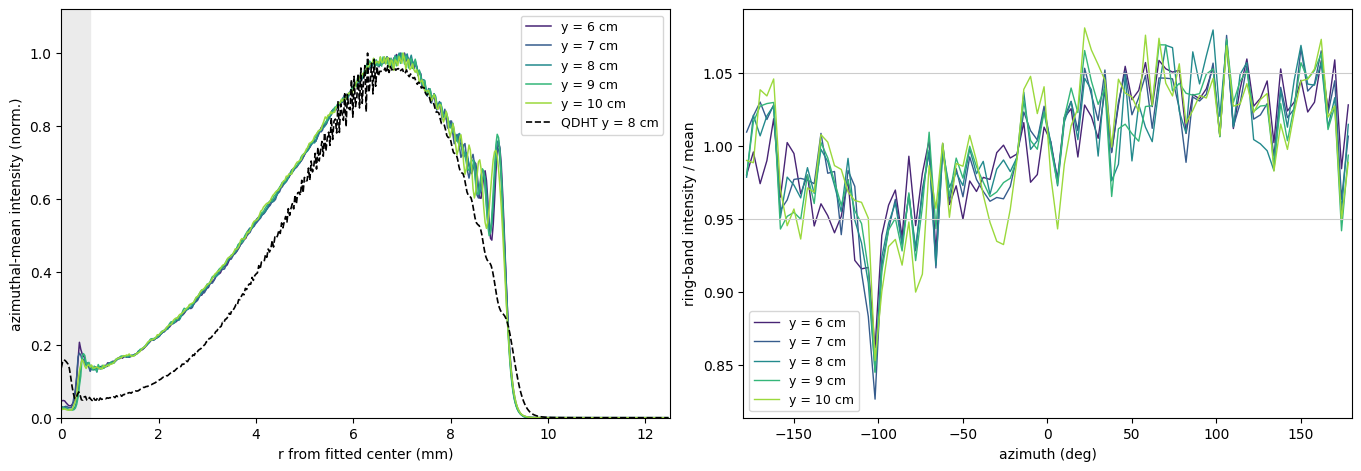

profile collapse, 4-10 mm band: rms spread 0.9% of ring peak
azimuthal rms per slice: 4.0%, 4.3%, 4.1%, 4.2%, 4.6%


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13.5, 4.6), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.85, 5))

ax = axs[0]
for s, c in zip(slices, colors):
    band = (s["r_mm"] > 4) & (s["r_mm"] < 11)
    ax.plot(s["r_mm"], s["prof"] / s["prof"][band].max(), color=c, lw=1.1,
            label=f"y = {s['y_cm']:g} cm")
Im = model[8.0]["I"]
bandq = (r_eval * 1e3 > 4) & (r_eval * 1e3 < 11)
ax.plot(r_eval * 1e3, Im / Im[bandq].max(), "k--", lw=1.2, label="QDHT y = 8 cm")
ax.axvspan(0, 0.6, color="0.92")           # blemish region
ax.set_xlim(0, 12.5); ax.set_ylim(0, 1.12)
ax.set_xlabel("r from fitted center (mm)")
ax.set_ylabel("azimuthal-mean intensity (norm.)")
ax.legend(fontsize=9)

ax = axs[1]
tb = np.arange(-180, 181, 4)
for s, c in zip(slices, colors):
    m = (s["rgrid"] > 5.5) & (s["rgrid"] < 8.0)
    ti = np.digitize(s["theta_deg"][m], tb)
    az = (np.bincount(ti, weights=s["canvas"][m], minlength=len(tb) + 1)[1:len(tb)]
          / np.maximum(np.bincount(ti, minlength=len(tb) + 1)[1:len(tb)], 1))
    az = az / az.mean()
    ax.plot(tb[:-1] + 2, az, color=c, lw=1.0, label=f"y = {s['y_cm']:g} cm")
    s["az_rms"] = az.std()
for lev in (0.95, 1.05):
    ax.axhline(lev, color="0.8", lw=0.8)
ax.set_xlim(-180, 180); ax.set_xlabel("azimuth (deg)")
ax.set_ylabel("ring-band intensity / mean")
ax.legend(fontsize=9)
save_fig("annulus_profiles")
plt.show()

prof_stack = np.array([s["prof"] / s["prof"][(s["r_mm"] > 4) & (s["r_mm"] < 11)].max()
                       for s in slices])
band = (slices[0]["r_mm"] > 4) & (slices[0]["r_mm"] < 10)
print(f"profile collapse, 4-10 mm band: rms spread "
      f"{prof_stack[:, band].std(axis=0).mean() * 100:.1f}% of ring peak")
print("azimuthal rms per slice:",
      ", ".join(f"{s['az_rms'] * 100:.1f}%" for s in slices))

### Verdict

- **The annulus is collimated.** The five radial profiles collapse to
  ~1 % of ring peak over 4–10 mm, and the outer edge moves at
  −3.5 ± 1.0 mrad against the 40.1 mrad cone that entered axicon 2 — the
  pair cancels the cone to ~1 part in 10. QDHT expects only ~−0.3 mrad of apparent
  (diffraction) edge motion, so the genuine residual convergence is
  ~−3 mrad (~2σ) — if real, focus near y ≈ 3.4 m, far beyond any planned L23.
  A longer-baseline scan on the next placement would pin it down.
- **Ring geometry matches QDHT; the interior does not.** Ring peak radius
  6.94–7.05 mm vs 6.76–6.87 model (+2 %, the same size as the +2 % on the
  ring *before* axicon 2), edge position within a few % on any one
  estimator. The real shape discrepancy: the measured FWHM is 5.0–5.4 mm vs
  4.3–4.4 model — all of the excess on the *inboard* side, where the
  **interior (r ≲ 6 mm) carries far more light than the model**, rising
  ~linearly from center instead of the model's Gaussian-tail floor. Same
  family as the ×25–600 near-axis excess in the axicon-1 axial scans:
  apex-region rounding/scatter, now folded through two apexes. Via the
  r → r/θ₃ mapping this interior light lands at the *front* of the eventual
  axicon-3 window — worth carrying into the L23/θ₃ design rather than
  assuming the ideal-model floor.
- **Azimuthal uniformity 4.0–4.6 % rms** (min/max ≈ 0.85/1.08) in the
  5.5–8 mm band, and the pattern repeats slice-to-slice (fixed dip near
  −100°) — source-side structure, not noise. Since the axicon-3 window
  integrates the annulus azimuthally at each z, this propagates to ~%-level
  axial ripple, not 15 %.
- **Axis tilt** vs gantry Y: (−4.2 ± 0.4, +4.8 ± 1.6) mrad in (X, Z) —
  ~6 mrad total, of which +2.5 mrad Z is the known input-beam pointing;
  fine for profiling, but it is the lever arm for where the bottle/lattice
  axis points downstream.
- **Brightness is consistent with the handoff.** Peak-pixel rates
  5.8–6.2×10⁻⁴ counts/µs across the five slices (composite 8×8-pooled
  peaks 2.6–2.9×10⁻⁴) — same order as the annulus plateau axicon 1 was
  delivering at 27–33 cm, so axicon 2 lost nothing gross; the ~10⁴ ratio to
  the axicon-1 core zone is why calibration ran 0.25–0.31 s exposures.
- **The center blemish** (dark ~0.7 mm oval + bright speck + faint streak
  at r ≈ 2 mm, identical in all five slices) sits on an optic, not in the
  beam; worth an inspection/clean before the axicon-3 build, though at
  these radii it folds only into the first ~few cm of the window.

**Open**: longer-baseline collimation scan; calibration dim-branch
"saturated pixel" bookkeeping (converged=False on every slice while no
raster frame saturates); optic inspection for the blemish; absolute-power
tie-in.